In [39]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [21]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

In [62]:
URL = (
    "https://geodaten-wasser.rlp-umwelt.de/"
    "api/data/messstellen_wasserstand_abflusswerte_30"
    "?w=messstellennummer=2377050700"
)

headers = {
    "User-Agent": (
        "Mozilla/5.0 (X11; Linux x86_64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/120.0 Safari/537.36"
    ),
    "Accept": "application/json, text/plain, */*",
    "Referer": "https://geodaten-wasser.rlp-umwelt.de/",
}

response = requests.get(URL, headers=headers, timeout=30)

print(response.status_code)
# print(response.text[:500])

data = response.json()

200


In [64]:
df = pd.DataFrame(data)

df = df.dropna(subset=["abfluss"])

df["datestring"] = pd.to_datetime(df["datestring"])

df["abfluss"] = (
        df["abfluss"]
        .str.replace(",", ".", regex=False)
        .pipe(pd.to_numeric)
    )

df = (
        df[["datestring", "abfluss"]]
        .rename(columns={
            "datestring": "timestamp",
            "abfluss": "discharge"
            })
        .set_index("timestamp")
        .sort_index()
    )


df

,discharge
timestamp,
2026-04-11 13:15:00+00:00,1.124
2026-04-11 13:30:00+00:00,1.124
2026-04-11 13:45:00+00:00,1.185
2026-04-11 14:00:00+00:00,1.124
2026-04-11 14:15:00+00:00,1.124
...,...
2026-05-12 11:00:00+00:00,1.006
2026-05-12 11:15:00+00:00,0.949
2026-05-12 11:30:00+00:00,1.006


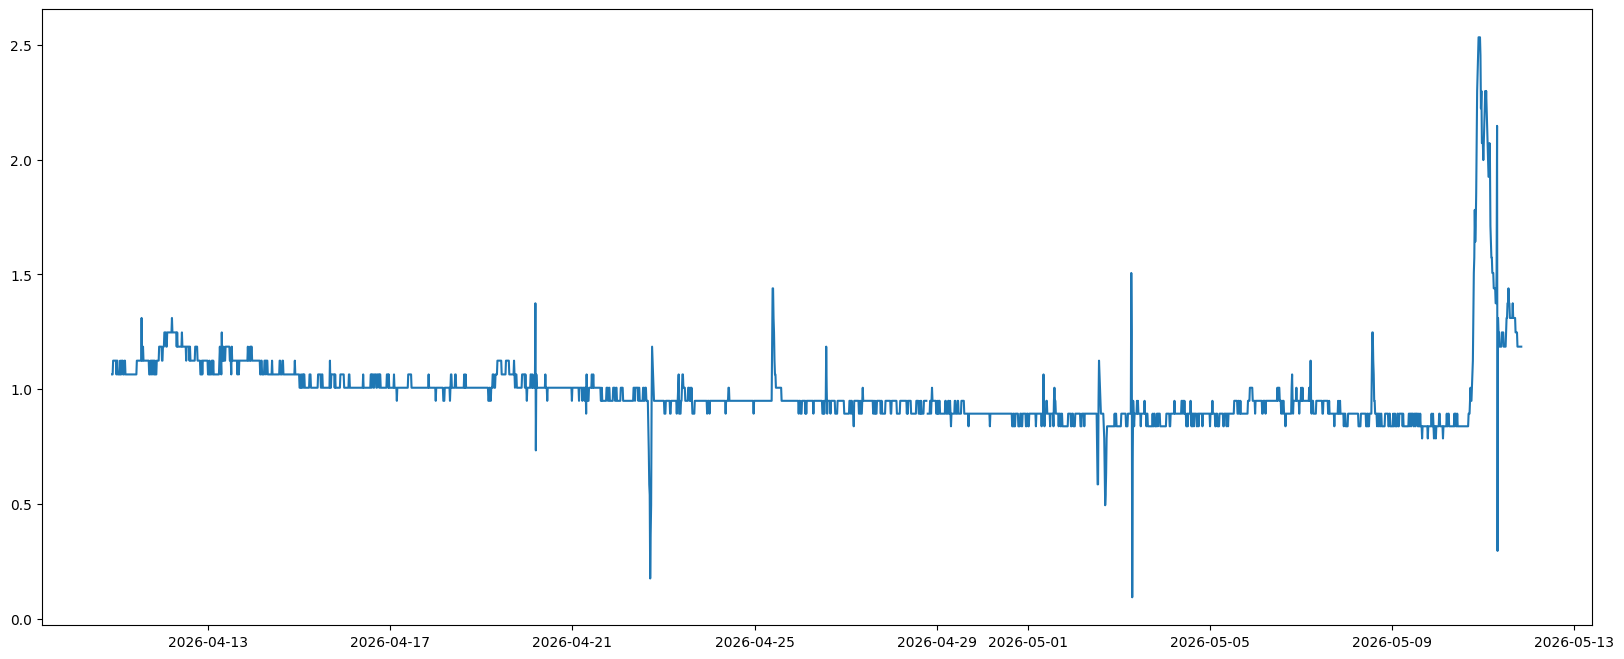

In [54]:
fig, ax = plt.subplots(figsize=(20,8))
ax.plot(df)
plt.show()


## Check bs4 Discharge scrape

In [ ]:
import requests
import pandas as pd

from bs4 import BeautifulSoup

URL = "https://www.hochwasser.rlp.de/flussgebiet/oberrhein/siebeldingen#abfluesse"


def fetch():

    response = requests.get(URL, timeout=30)
    response.raise_for_status()

    soup = BeautifulSoup(
        response.text,
        "html.parser",
    )

    rows = soup.select(
        ".m-detail-measurementsites__table-row__details"
    )

    data = []

    for row in rows:

        cells = row.select(
            ".m-detail-measurementsites__table-cell"
        )

        if len(cells) < 3:
            continue

        weekday = cells[0].get_text(strip=True)

        time_str = cells[1].get_text(strip=True)

        value_str = cells[2].get_text(strip=True)

        value = (
            value_str
            .replace("m³/s", "")
            .replace(",", ".")
            .strip()
        )

        data.append({
            "weekday": weekday,
            "time": time_str,
            "discharge": float(value),
        })

    df = pd.DataFrame(data)

    return df

In [30]:
HEADERS  = {
    "User-Agent": (
        "Mozilla/5.0 (X11; Linux x86_64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/120.0 Safari/537.36"
    ),
    "Accept": "application/json, text/plain, */*",
    "Referer": "https://geodaten-wasser.rlp-umwelt.de/",
}

In [31]:
response = requests.get(URL, headers=HEADERS, timeout=30)
response.raise_for_status()

soup = BeautifulSoup(
    response.text,
    "html.parser",
)

<!DOCTYPE html>
<html lang="de"><head><meta charset="utf-8"/><link href="/favicon.ico" rel="icon"/><link href="/apple-touch-icon-180x180.png" rel="apple-touch-icon" sizes="180x180"/><link href="/favicon-32x32.png" rel="icon" sizes="32x32" type="image/png"/><link href="/favicon-16x16.png" rel="icon" sizes="16x16" type="image/png"/><link href="/manifest.json" rel="manifest"/><meta content="width=device-width,initial-scale=1,maximum-scale=1,user-scalable=0" name="viewport"/><meta content="#000000" name="theme-color"/><meta content="Hochwasservorhersagezentrale Rheinland-Pfalz" name="description"/><meta content="Landesamt fÃ¼r Umwelt, Wasserwirtschaft und Gewerbeaufsicht Rheinland-Pfalz" name="author"/><link href="/manifest.json" rel="manifest"/><title>Hochwasservorhersagezentrale Rheinland-Pfalz</title><script>function setViewportProperty(e){var t;function n(){var n=e.clientHeight;n!==t&&requestAnimationFrame((function(){e.style.setProperty("--vh",.009999*n+"px"),t=n}))}return n(),n}windo

In [28]:
rows = soup.select(
    "MuiAccordionDetails-root"
)
rows

[]

In [21]:
df = fetch()
df

""


## Develope daily precip data

In [30]:
from tqdm import tqdm
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

import rasterio
from rasterio.windows import Window

import bz2
import shutil
import xarray as xr


### ICON-D2

In [1]:
%load_ext autoreload
%autoreload 2

In [46]:
from pathlib import Path
import pandas as pd
import geopandas as gpd
import xarray as xr

from configs.jobs_config import DECOMPRESSED_DIR, ICON_OUTPUT_DIR, CATCHMENT_PATH, CLIP_CRS
from utils.logger import logger
from jobs.icon.process import clip_to_catchment, extract_precip_timeseries, build_precip_timeseries
from jobs.icon.ingest_icon import fetch_icon, decompress_bz2_dir, write_to_db
from database.queries import load_precip_forecast_data

In [166]:
from configs.jobs_config import ICON_URL, ICON_OUTPUT_DIR
from jobs.icon.fetch_icon import fetch_icon_metadata, get_local_forecast_times

In [167]:
df_remote = fetch_icon_metadata(url=ICON_URL)

local_times = get_local_forecast_times(directory=ICON_OUTPUT_DIR)

df_missing = df_remote[
    ~df_remote["datetime_forecast"].isin(local_times)
]

In [170]:
df = load_precip_forecast_data()
df[df["precip_mean"] < 0] = 0

expected = pd.date_range(df.index.min(), df.index.max(), freq="15min")
missing = expected.difference(df.index)

missing

DatetimeIndex(['2026-05-19 00:00:00', '2026-05-19 00:15:00',
               '2026-05-19 00:30:00', '2026-05-19 00:45:00',
               '2026-05-19 01:00:00', '2026-05-19 01:15:00',
               '2026-05-19 01:30:00', '2026-05-19 01:45:00',
               '2026-05-19 02:00:00', '2026-05-19 02:15:00',
               ...
               '2026-05-22 21:30:00', '2026-05-22 21:45:00',
               '2026-05-22 22:00:00', '2026-05-22 22:15:00',
               '2026-05-22 22:30:00', '2026-05-22 22:45:00',
               '2026-05-22 23:00:00', '2026-05-22 23:15:00',
               '2026-05-22 23:30:00', '2026-05-22 23:45:00'],
              dtype='datetime64[ns]', length=384, freq='15min')

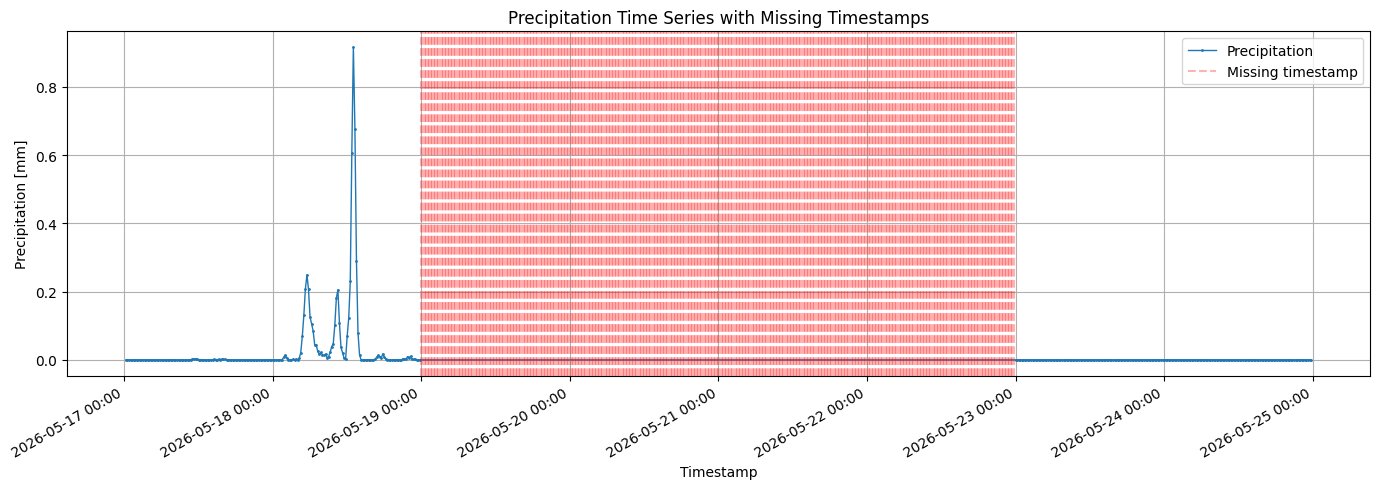

In [171]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


# expected full timeline
expected = pd.date_range(
    start=df.index.min(),
    end=df.index.max(),
    freq="15min"   # change if needed
)

# missing timestamps
missing = expected.difference(df.index)

fig, ax = plt.subplots(figsize=(14, 5))

# precipitation timeseries
ax.plot(
    df.index,
    df["precip_mean"],
    marker="o",
    markersize=1,
    linewidth=1,
    label="Precipitation"
)

# red vertical markers for missing timestamps
for ts in missing:
    ax.axvline(
        x=ts,
        linestyle="--",
        color="red",
        alpha=0.3,
        label="Missing timestamp" if ts == missing[0] else ""
    )


ax.set_title("Precipitation Time Series with Missing Timestamps")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Precipitation [mm]")

# datetime formatting
ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%Y-%m-%d %H:%M")
)
fig.autofmt_xdate()

ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()

______________________________________________________________________

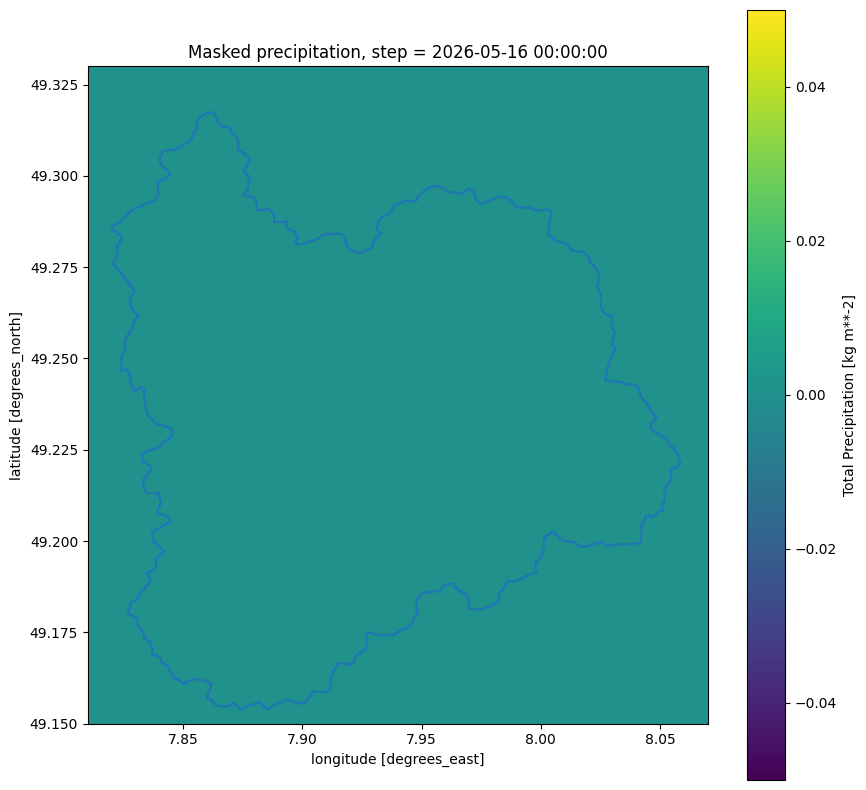

In [62]:
import matplotlib.pyplot as plt
# Select one timestep
step = 1
sample = precip_cropped.isel(step=step)
# sample = precip_masked.isel(step=0)

fig, ax = plt.subplots(figsize=(10, 10))

# Plot precipitation raster
sample.plot(ax=ax)

# Overlay watershed border
catchment.boundary.plot(
    ax=ax,
)

plt.title(f"Masked precipitation, step = {pd.to_datetime(sample.time.values)}")
plt.show()

________________________________________________________________________________________________________

### RADOLAN PRECIP


In [251]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [32]:
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import tarfile
import wradlib as wrl
import xarray
import rioxarray

import matplotlib.pyplot as plt
import contextily as ctx

from configs.jobs_config import RADOLAN_DECOMPRESSED_DIR, CATCHMENT_PATH
from jobs.radolan.fetch_radolan import fetch_radolan
from jobs.radolan.decompress_radolan import decompress_tar_dir

from jobs.radolan.process_radolan import build_precip_timeseries

from database.queries import load_precip_observation_data

In [ ]:

df = load_precip_observation_data()

In [63]:
df[df.index > "2026-05-10"]

,precip_mean
timestamp,
2026-05-10 00:15:00,0.0
2026-05-10 00:30:00,0.0
2026-05-10 00:45:00,0.0
2026-05-10 01:00:00,0.0
2026-05-10 01:15:00,0.0
...,...
2026-05-24 22:45:00,0.0
2026-05-24 23:00:00,0.0
2026-05-24 23:15:00,0.0


<Axes: xlabel='timestamp'>

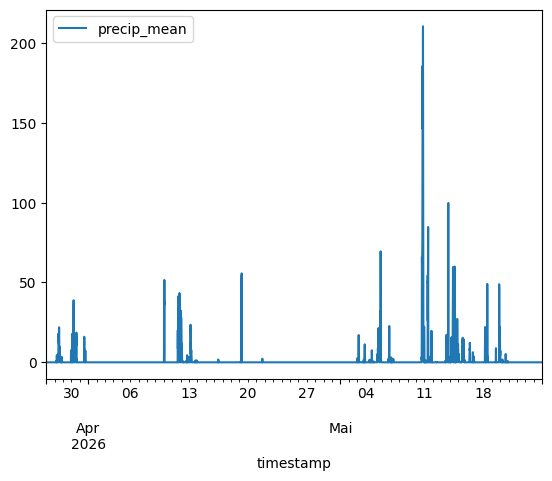

In [57]:
df.plot()

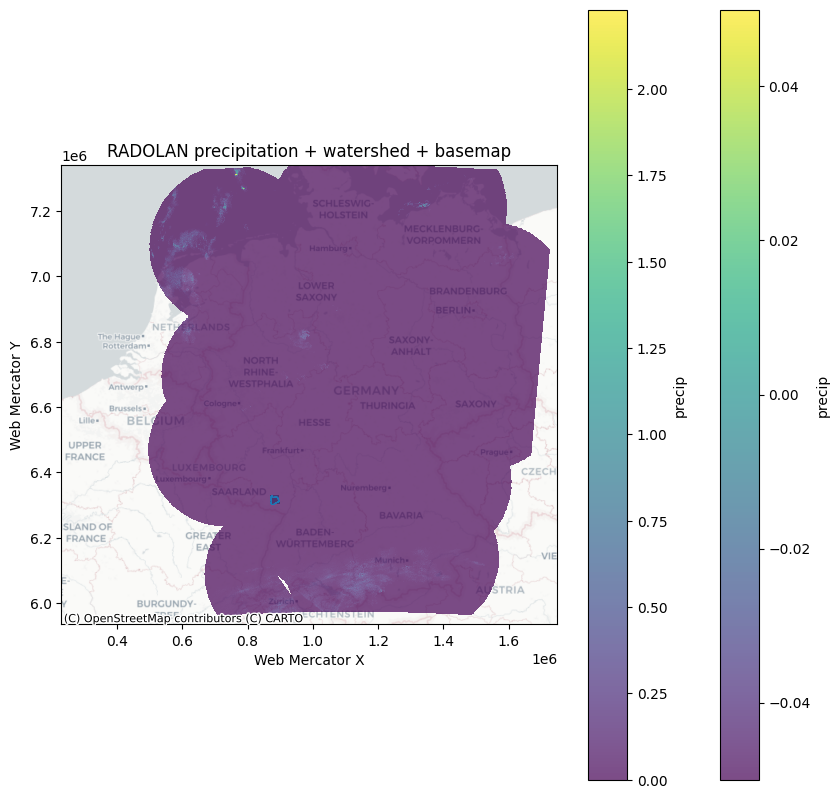

In [607]:
# --- reproject to Web Mercator for basemap ---
data_xr_3857 = data_xr.rio.reproject("EPSG:3857")
precip_clipped_3857 = precip_clipped.rio.reproject("EPSG:3857")
catchment_3857 = catchment.to_crs("EPSG:3857")

# --- plot ---
fig, ax = plt.subplots(figsize=(10, 10))

# raster
precip_clipped_3857.plot(
    ax=ax,
    alpha=0.7,   # slightly transparent
    add_colorbar=True
)

# raster
data_xr_3857.plot(
    ax=ax,
    alpha=0.7,   # slightly transparent
    add_colorbar=True
)

# catchment boundary
catchment_3857.boundary.plot(
    ax=ax,
    linewidth=0.5,
)

# basemap
ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Positron
)

ax.set_title("RADOLAN precipitation + watershed + basemap")
ax.set_xlabel("Web Mercator X")
ax.set_ylabel("Web Mercator Y")
ax.set_aspect("equal")

plt.show()

In [416]:
watershed = gpd.read_file("data/catchment/catchment_queich_siebeldingen.gpkg")

# reproject shape to RADOLAN CRS
watershed = watershed.to_crs(data_proj.rio.crs)

# Missing values
data_proj = data_proj.where(data_proj != -9999)

clipped = data_proj.rio.clip(
    watershed.geometry,
    watershed.crs,
    drop=True
)

clipped.plot()
plt.show()

NoDataInBounds: No data found in bounds. Data variable: precip

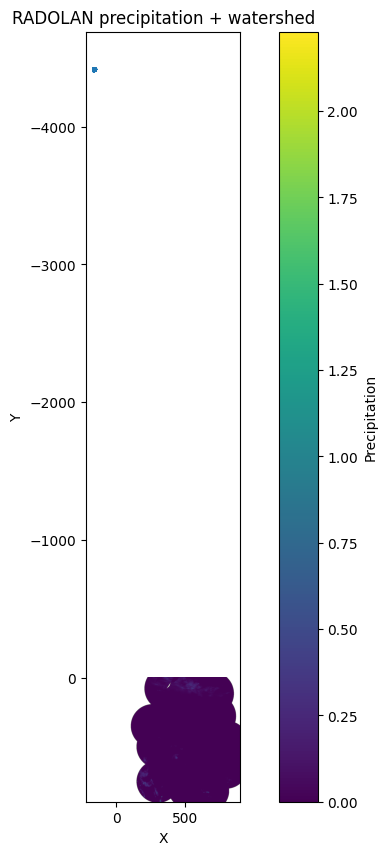

In [429]:
# RADOLAN data
data, attrs = wrl.io.read_radolan_composite(file_paths[0])

# nodata -> NaN
data = data.astype(float)
data[np.isclose(data, -9999)] = np.nan
# data = np.where(array == -9999, np.nan, array)

# RADOLAN coordinates
grid = wrl.georef.get_radolan_grid(
    attrs["nrow"],
    attrs["ncol"]
)

x = grid[:, :, 0]
y = grid[:, :, 1]

# watershed in RADOLAN CRS
radolan_crs = wrl.georef.projection.create_crs("dwd-radolan")
watershed = watershed.to_crs(radolan_crs)

# plot
fig, ax = plt.subplots(figsize=(10, 10))

# raster
# mesh = ax.pcolormesh(
mesh = ax.imshow(
    # x,
    # y,
    data,
    # shading="auto"
)

# watershed overlay
watershed.boundary.plot(
    ax=ax,
    linewidth=2
)

plt.colorbar(mesh, ax=ax, label="Precipitation")
ax.set_title("RADOLAN precipitation + watershed")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_aspect("equal")

plt.show()

In [400]:
coords[:, :, 1]

array([[-4658.64472427, -4658.64472427, -4658.64472427, ...,
        -4658.64472427, -4658.64472427, -4658.64472427],
       [-4657.64472427, -4657.64472427, -4657.64472427, ...,
        -4657.64472427, -4657.64472427, -4657.64472427],
       [-4656.64472427, -4656.64472427, -4656.64472427, ...,
        -4656.64472427, -4656.64472427, -4656.64472427],
       ...,
       [-3761.64472427, -3761.64472427, -3761.64472427, ...,
        -3761.64472427, -3761.64472427, -3761.64472427],
       [-3760.64472427, -3760.64472427, -3760.64472427, ...,
        -3760.64472427, -3760.64472427, -3760.64472427],
       [-3759.64472427, -3759.64472427, -3759.64472427, ...,
        -3759.64472427, -3759.64472427, -3759.64472427]], shape=(900, 900))

In [ ]:
data_projected = xr.DataArray(
    data,
    dims=("y", "x"),
    coords={
        "x": x[0, :],
        "y": y[:, 0],
    },
    name="precip"
)

### Check queries

In [69]:
from jobs.radolan.process_radolan import read_radolan_data

In [71]:
path = "data/observed_precip/radolan/decompressed/YW-260510/raa01-yw_10000-2605101830-dwd---bin"
ds = read_radolan_data(file_path=path)

In [72]:
ds

(array([[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]], shape=(900, 900)),
 {'producttype': 'YW',
  'datetime': datetime.datetime(2026, 5, 10, 18, 30),
  'radarid': '10000',
  'nrow': 900,
  'ncol': 900,
  'datasize': 1620000,
  'formatversion': 2,
  'maxrange': '128 km',
  'radolanversion': '2.29.1',
  'precision': 0.01,
  'intervalseconds': 300,
  'radarlocations': ['asb',
   'boo',
   'ros',
   'hnr',
   'umd',
   'pro',
   'ess',
   'fld',
   'drs',
   'neu',
   'nhb',
   'oft',
   'eis',
   'tur',
   'isn',
   'fbg',
   'mem'],
  'nodataflag': -9999,
  'secondary': array([], dtype=int64),
  'nodatamask': array([     0,      1,      2, ..., 809997, 809998, 809999],
        shape=(181149,)),
  'cluttermask': array([], dtype=int64)})

In [ ]:
def load_timeseries(
    model,
    value_column: str,
    output_name: str,
    start: pd.Timestamp | None = None,
    end: pd.Timestamp | None = None,
) -> pd.DataFrame:
    
    session = SessionLocal()

    try:
        statement = select(model)

        if start is not None:
            statement = statement.where(model.timestamp >= start)

        if end is not None:
            statement = statement.where(model.timestamp < end)

        statement = statement.order_by(model.timestamp)

        rows = session.execute(statement).scalars().all()

        df = pd.DataFrame(
            [
                {
                    "timestamp": r.timestamp,
                    output_name: getattr(r, value_column),
                }
                for r in rows
            ]
        )

        if not df.empty:
            df = df.set_index("timestamp")

        return df

    finally:
        session.close()

In [46]:
import matplotlib.pyplot as plt
from database.queries import load_discharge_data, load_inference_data, load_precip_observation_data, load_precip_forecast_data

In [81]:
df_discharge = load_discharge_data()
df_inference = load_inference_data()
df_precip_observation = load_precip_observation_data()
df_precip_forecast = load_precip_forecast_data()

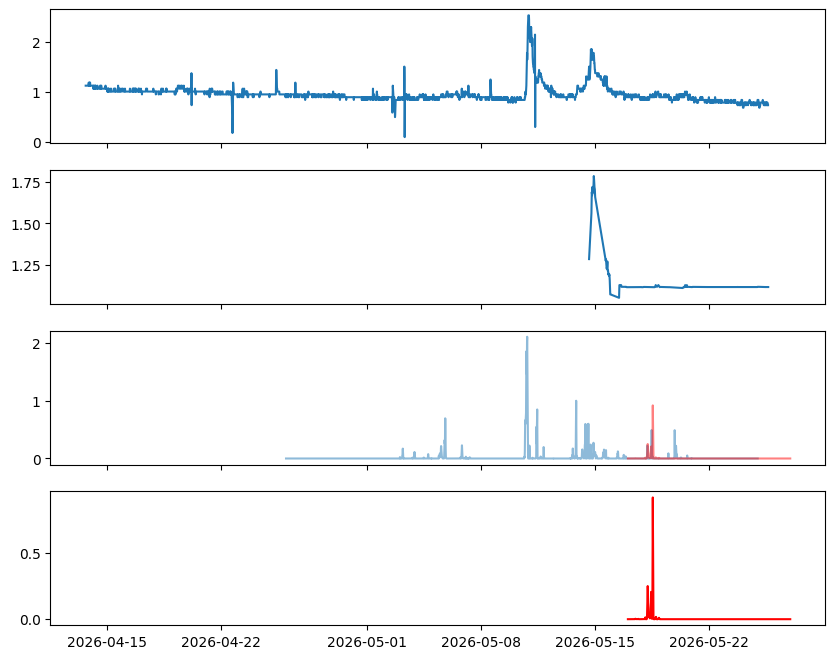

In [83]:
fig, axs = plt.subplots(figsize = (10,8), nrows=4, sharex=True)

axs[0].plot(df_discharge)
axs[1].plot(df_inference)
axs[2].plot(df_precip_observation, alpha=0.5)
axs[2].plot(df_precip_forecast[df_precip_forecast >= 0], color="red", alpha=0.5)
axs[3].plot(df_precip_forecast[df_precip_forecast >= 0], color="red")

plt.show()

In [75]:
from database.db import SessionLocal
from database.models import RadolanPrecipObservation

In [74]:
session = SessionLocal()

In [76]:
session.query(RadolanPrecipObservation).delete()
session.commit()
session.close()